
<font color=#009afa size=50>Visualisation of Data</font>

<font size=50>2 - Graphs from Satellite Dataset</font>


|**Assessment Code:** |PRES1|
|---|---|
|**Author:**|Tom Rowan, ST20285213|
|**Course:**| DAT5001_S2_25|
|**Course Tutor:**| ***** Dr. Imtiaz *****|

## Part 1



Issues:
- Kessler Syndrome (https://aquarid.physics.uwo.ca/kessler/Kessler%20Syndrome-AAS%20Paper.pdf)
- Rocket Launches - CO2 impact

Falcon 9 Rocket (https://sma.nasa.gov/LaunchVehicle/assets/spacex-falcon-9-data-sheet.pdf)

Copilot says:

A single SpaceX Falcon 9 launch uses approximately 507,500 kilograms (about 507.5 metric tonnes) of propellant, which consists of:

RP-1 (rocket-grade kerosene): ~112,184 kg
Liquid Oxygen (LOX): ~395,316 kg

This total is based on the Falcon 9 Full Thrust (Block 5) version, which is the current operational variant. The rocket is a two-stage launch vehicle, and both stages use RP-1 and LOX as propellants.
Breakdown by Stage

First Stage:

Propellant mass: ~395,700 kg
Burn time: ~162 seconds
Engines: 9 Merlin 1D


Second Stage:

Propellant mass: ~92,670 kg
Burn time: ~397 seconds
Engine: 1 Merlin Vacuum



These figures are derived from technical specifications and performance analyses. [wevolver.com]
Environmental Impact
Each Falcon 9 launch emits approximately 336,552 kg of CO₂, based on the combustion of RP-1 kerosene. [championtraveler.com]
Sources

Wevolver Falcon 9 Block 5 Specs [wevolver.com]
Champion Traveler CO₂ Analysis [championtraveler.com]
Wikipedia Falcon 9 Overview [en.wikipedia.org]

As of October 2025, SpaceX typically launches 28 Starlink satellites per Falcon 9 mission. [extremetech.com], [arstechnica.com], [msn.com]
This number has decreased over time due to the satellites becoming larger and more capable. Earlier in the Starlink program (around 2019–2020), Falcon 9 launches carried up to 60 satellites per flight. However, the current V2 Mini satellites are more advanced and heavier, which limits the number that can be carried per launch.

https://www.extremetech.com/aerospace/spacex-sends-10000th-starlink-satellite-into-orbit-with-latest-falcon-9




 D.J. Kessler and B.G. Cour-Palais, "Collision Frequency of Artificial Satellites: The Creation of a Debris Belt", Journal of Geophysical Research, Vol. 83, No. A6, pp. 2637-2646, June 1, 1978. 
Available at: https://www.freelists.org/archives/arocket/05-2025/pdfhf1FIX9bCw.pdf
Accessed 22/10/2025




## Code for Graphs below

In [1]:
# Install Requirements Using Pip
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [19]:
# Standard Libraries
import json
import random
from datetime import datetime
import sys

# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.pyplot import figure
%matplotlib inline

# Seaborn Graphs
import seaborn as sns

# Cartopy Maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Geopandas
import geopandas as gpd

# GeoPy
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

# Pycountry 
import pycountry

# Plotly
import plotly.express as px

# Tabulate
from tabulate import tabulate

# Colorama
from colorama import Fore, Back, Style

# Do not print warnings!
import warnings
warnings.filterwarnings('ignore')

In [3]:
sdf = pd.read_csv('../../datasets/cleaned_engineered_sdf.csv')

In [11]:
custom_palette = ['#4977AAff','#FFBD02ff','#395B83ff','#989DB1ff','#686347ff','#FFFFFFff','#565E5Eff','#3E4A58ff']


In [4]:
sdf.shape

(66317, 51)

In [5]:
sdf.columns

Index(['Unnamed: 0', 'Apogee', 'Category', 'Class', 'Class Desc', 'CosparID',
       'Country', 'Country Code', 'Decay Date', 'Decay Month',
       'Decay Month No', 'Decay Year', 'Diameter', 'In Orbit', 'InOrbit',
       'Inc', 'Launch Date', 'Launch Month', 'Launch Month No', 'Launch Year',
       'Length', 'Lifespan Days', 'Lifespan Months', 'Lifespan Years',
       'Manufacturer Code', 'Manufacturer Latitude', 'Manufacturer Long Name',
       'Manufacturer Longitude', 'Manufacturer Parent',
       'Manufacturer Short Name', 'Mass', 'Name', 'Operator Code',
       'Operator Latitude', 'Operator Long Name', 'Operator Longitude',
       'Operator Parent', 'Operator Short Name', 'Perigee', 'Primary Category',
       'Primary Category Desc', 'Program', 'Secondary Category',
       'Secondary Category Desc', 'Shape', 'Span', 'State', 'Status',
       'Status Desc', 'Type', 'Type Desc'],
      dtype='object')

## Graphs for Presentation

Need to create:

- Objects added by year, showing remaining in orbit
- Pie chart: Breakdown of objects by category (satellites, rocket bodies, debris).
- Bar chart: Payload categories (military, comms, scientific, etc.).
- Bar chart or map: Top countries or organisations responsible for objects in orbit.
- Histogram: Time between launch and re-entry for satellites.
- Visual: Timeline or scatter plot of known collisions or near misses. ... where do we get this data?


In [37]:

# Filter for Type == 'P'
filtered_df = sdf[sdf['Type'] == 'P']

# Drop rows with missing values in hierarchy columns
filtered_df = filtered_df.dropna(subset=['Country', 'Class Desc'])

# Aggregate counts for clarity
agg_df = filtered_df.groupby(['Country', 'Class Desc']).size().reset_index(name='Count')


# Step 5: Create sunburst chart
fig = px.sunburst(
    agg_df,
    path=['Class Desc', 'Country'],
    values='Count',
    title='Top 20 Countries by Object Volume (Grouped by Class)',
    color='Country'
)

fig.update_layout(
    width=1200,   # Increase width (default is ~700)
    height=800,   # Increase height (default is ~450)
    margin=dict(t=50, l=25, r=25, b=25)
)
fig.show()


### More fun stuff below :)

In [46]:
avg_lifetime = sdf[sdf['Type Desc'].str.startswith('P', na=False)].groupby('Country')['Lifespan Years'].mean().reset_index()
avg_lifetime.columns = ['Country', 'AvgLifetime']
avg_lifetime = avg_lifetime.sort_values('AvgLifetime', ascending=False).head(20)

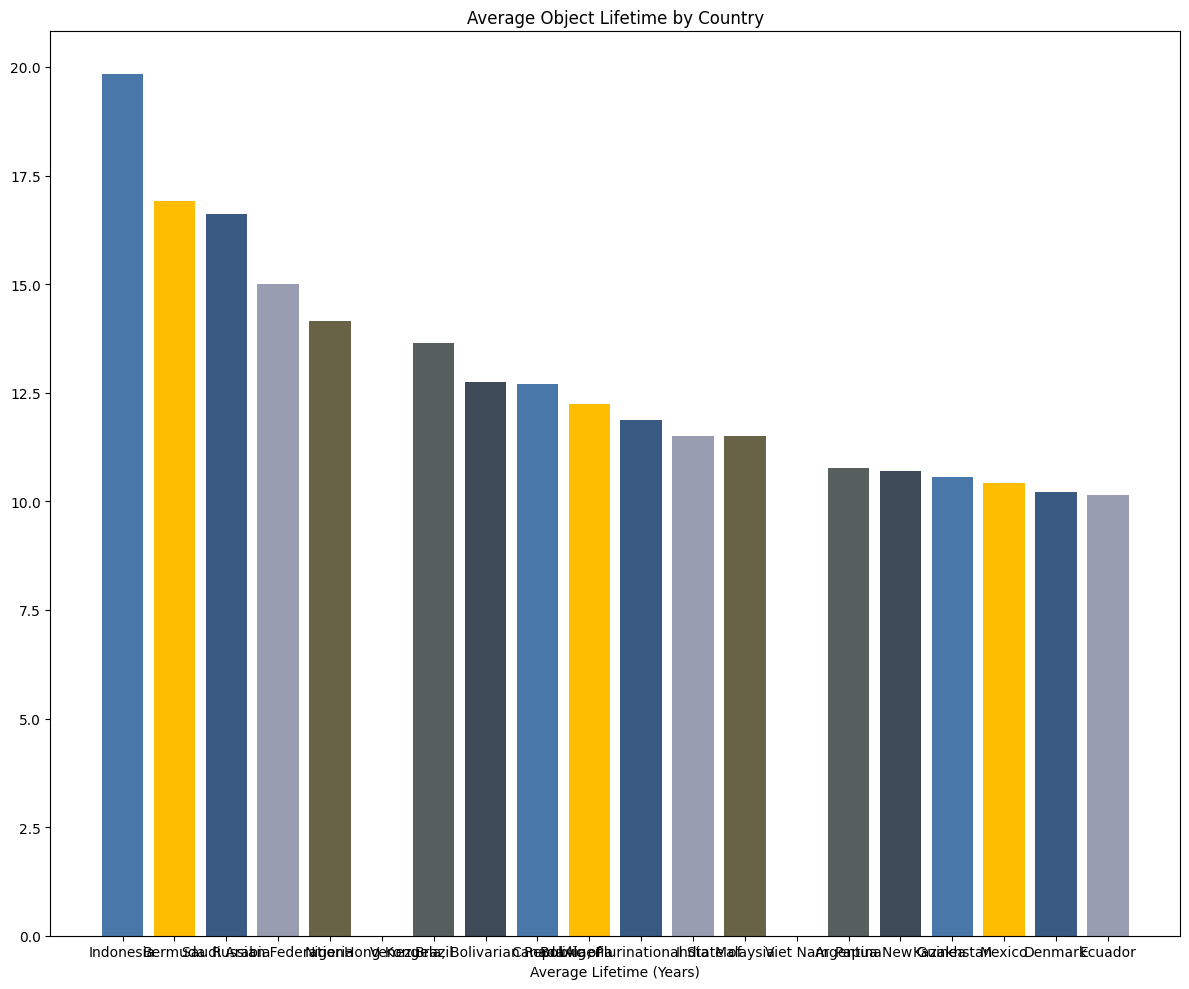

In [47]:
plt.figure(figsize=(12, 10))
plt.bar(avg_lifetime['Country'], avg_lifetime['AvgLifetime'], color=custom_palette)
plt.xlabel('Average Lifetime (Years)')
plt.title('Average Object Lifetime by Country')
plt.tight_layout()
plt.show()

In [48]:
# Filter non payloads
# sdf = sdf[sdf['Type'].str.startswith('P', na=False)]

In [49]:

# Group by LYear and Type, then count
grouped = sdf.groupby(['LYear', 'Type']).size().unstack(fill_value=0).sort_index()

# Plotting
plt.figure(figsize=(15, 8))
grouped.plot(kind='bar', stacked=True, color=custom_palette, width=0.8)

plt.title('Number of Objects Added per Year by Type')
plt.xlabel('Year')
plt.ylabel('Object Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

KeyError: 'LYear'

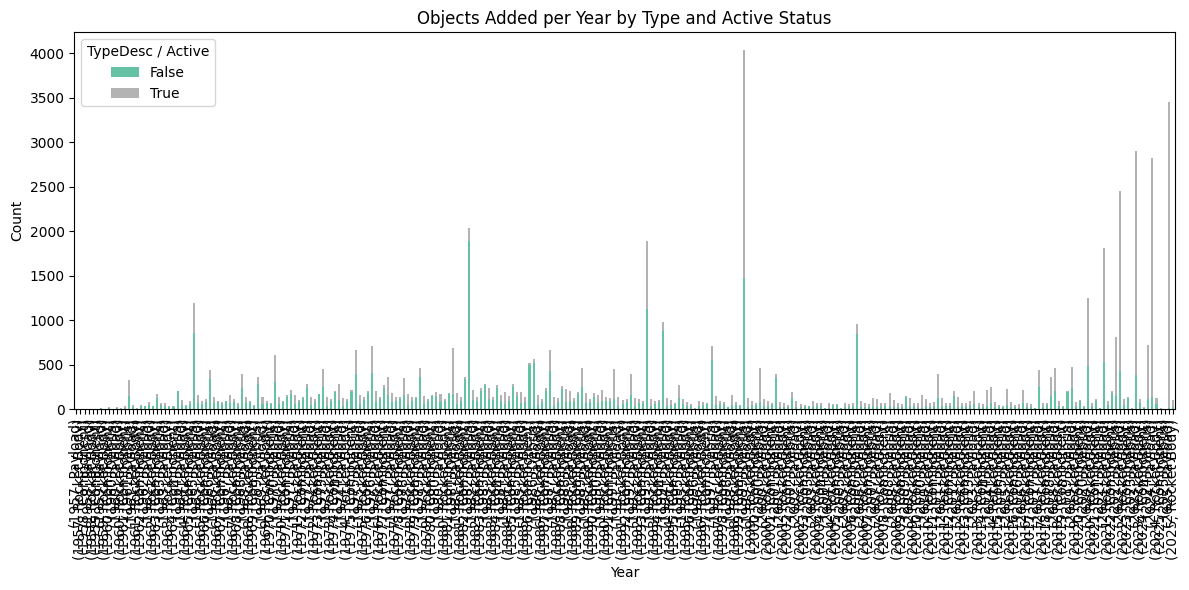

In [ ]:
grouped = sdf.groupby(['LYear', 'TypeDesc', 'Active']).size().unstack(fill_value=0)

# Plotting
grouped.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')
plt.title('Objects Added per Year by Type and Active Status')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='TypeDesc / Active')
plt.tight_layout()
plt.show()

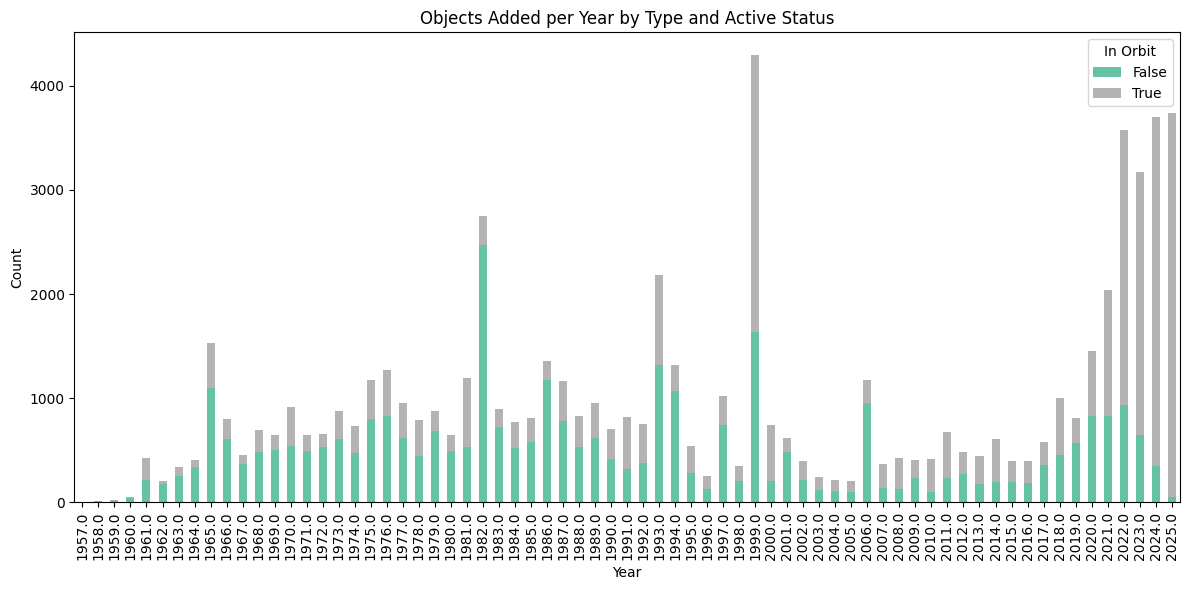

In [52]:
grouped = sdf.groupby(['Launch Year', 'In Orbit']).size().unstack(fill_value=0)

# Plotting
grouped.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')
plt.title('Objects Added per Year by Type and Active Status')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='In Orbit')
plt.tight_layout()
plt.show()

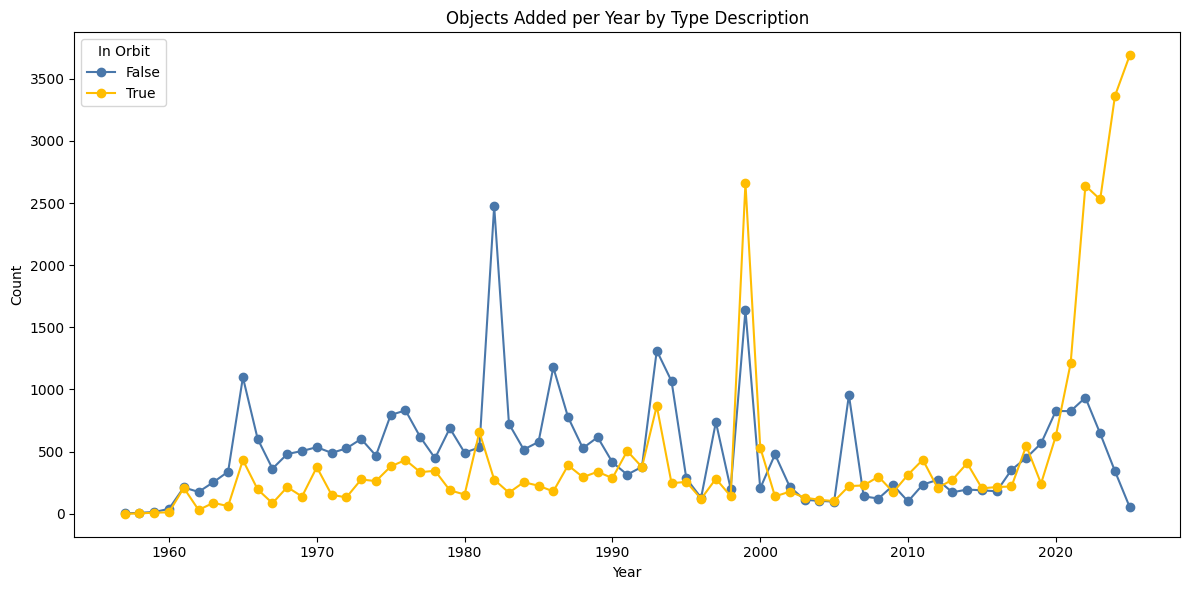

In [56]:
grouped = sdf.groupby(['Launch Year',  'In Orbit']).size().unstack(fill_value=0).sort_index()
#'Type Desc',
grouped.plot(kind='line', marker='o', figsize=(12, 6), color=custom_palette)
plt.title('Objects Added per Year by Type Description')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='In Orbit')
plt.tight_layout()
plt.show()

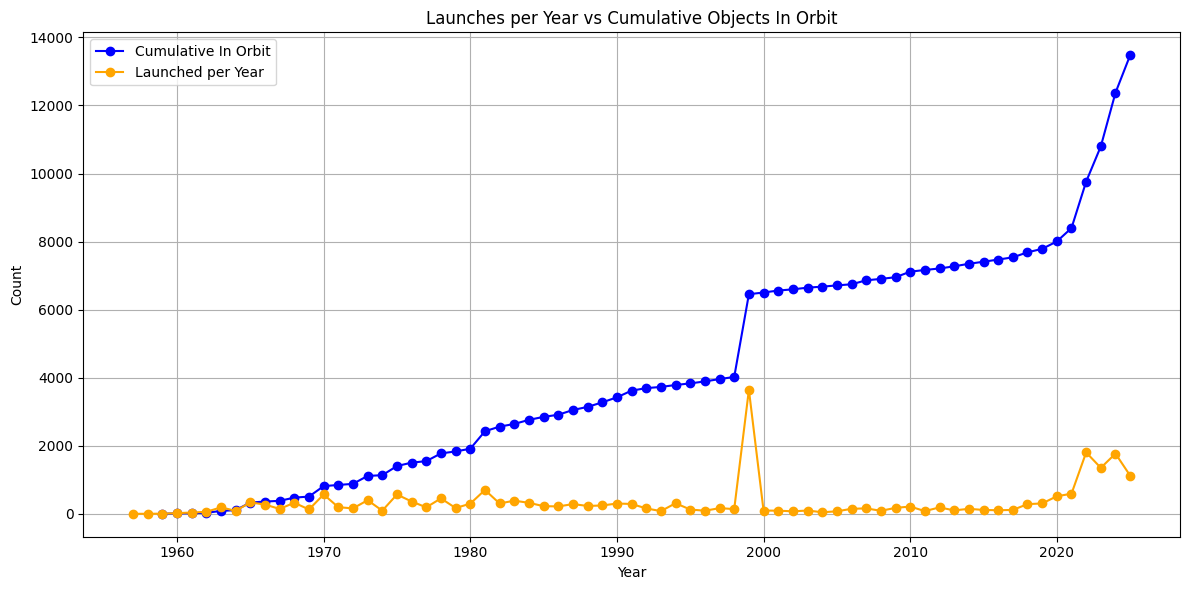

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure dates are parsed
sdf['Launch Date'] = pd.to_datetime(sdf['Launch Date'], errors='coerce')

# Filter for objects still in orbit
in_orbit_df = sdf[sdf['In Orbit'] == True].dropna(subset=['Launch Date'])

# Group by year for cumulative count
cumulative_by_year = in_orbit_df.groupby(in_orbit_df['Launch Date'].dt.year).size().cumsum()

# Group by year for launches (all objects)
launches_by_year = sdf.dropna(subset=['Launch Date']).groupby(sdf['Launch Date'].dt.year).size()

# Plot both series
plt.figure(figsize=(12, 6))
plt.plot(cumulative_by_year.index, cumulative_by_year.values, label='Cumulative In Orbit', color='blue', marker='o')
plt.plot(launches_by_year.index, launches_by_year.values, label='Launched per Year', color='orange', marker='o')

# Customise chart
plt.title('Launches per Year vs Cumulative Objects In Orbit')
plt.xlabel('Year')
plt.ylabel('Count')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [74]:
import plotly.graph_objects as go

fig = go.Figure()

# Add cumulative line
fig.add_trace(go.Scatter(
    x=cumulative_by_year.index,
    y=cumulative_by_year.values,
    #mode='lines+markers',
    mode='lines',
    name='Cumulative In Orbit',
    line=dict(color='#4977AA', width=3),
    marker=dict(color='white', size=6)
))

# Add yearly launches as bars
fig.add_trace(go.Bar(
    x=launches_by_year.index,
    y=launches_by_year.values,
    name='Launches per Year',
    marker_color='#FFBD02'
))

# Apply custom styling
fig.update_layout(
    title='Launches vs Cumulative Objects In Orbit',
    title_font=dict(color='#FFBD02', size=22),
    plot_bgcolor='#0F1A38',
    paper_bgcolor='#0F1A38',
    font=dict(color='white'),
    xaxis=dict(title='Year', color='white', gridcolor='white'),
    yaxis=dict(title='Count', color='white', gridcolor='white'),
    legend=dict(font=dict(color='white')),
    barmode='overlay',
    width=1200,
    height=700
)

fig.show()

In [66]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=cumulative_by_year.index, y=cumulative_by_year.values,
                         mode='lines+markers', name='Cumulative In Orbit'))
fig.add_trace(go.Bar(x=launches_by_year.index, y=launches_by_year.values,
                     name='Launches per Year'))

fig.update_layout(title='Launches vs Cumulative Objects In Orbit',
                  xaxis_title='Year', yaxis_title='Count',
                  barmode='overlay', width=1200, height=700)
fig.show()

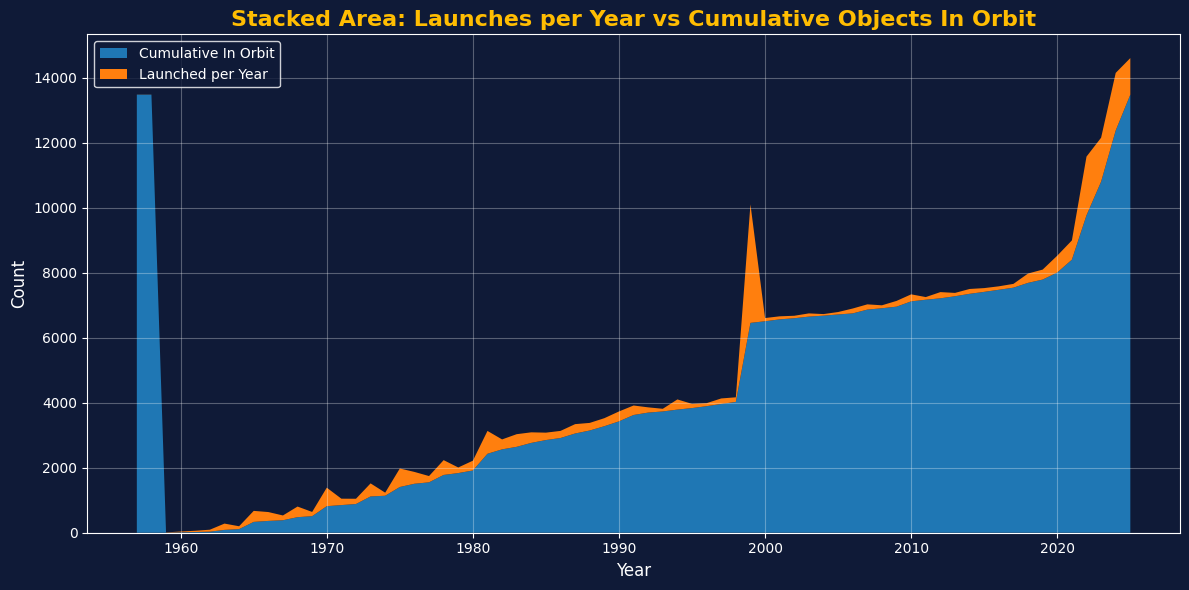

In [67]:
import matplotlib.pyplot as plt

# Plot stacked area chart
plt.figure(figsize=(12, 6))
plt.stackplot(years, cumulative, launches,
              labels=['Cumulative In Orbit', 'Launched per Year'],
              colors=['#1f77b4', '#ff7f0e'])

# Customise chart appearance
plt.title('Stacked Area: Launches per Year vs Cumulative Objects In Orbit',
          color='#FFBD02ff', fontsize=16, fontweight='bold')
plt.xlabel('Year', color='white', fontsize=12)
plt.ylabel('Count', color='white', fontsize=12)

# Set background colour
plt.gcf().set_facecolor('#0f1a37ff')  # Figure background
plt.gca().set_facecolor('#0f1a37ff')  # Plot area background

# Set tick and grid colours
plt.tick_params(axis='x', colors='white')
plt.tick_params(axis='y', colors='white')
plt.grid(alpha=0.3, color='white')

# Set legend text colour and background
legend = plt.legend(loc='upper left')
for text in legend.get_texts():
    text.set_color('white')
legend.get_frame().set_facecolor('#0f1a37ff')
legend.get_frame().set_edgecolor('white')

# Set axis spines to white
for spine in plt.gca().spines.values():
    spine.set_color('white')

plt.tight_layout()
plt.show()

In [69]:
import plotly.graph_objects as go

# Prepare data
years = sorted(set(cumulative_by_year.index).union(set(launches_by_year.index)))
cumulative = [cumulative_by_year.get(year, cumulative_by_year.iloc[-1]) for year in years]
launches = [launches_by_year.get(year, 0) for year in years]

# Create figure
fig = go.Figure()

# Add cumulative area
fig.add_trace(go.Scatter(
    x=years, y=cumulative,
    mode='lines',
    fill='tonexty',
    name='Cumulative In Orbit',
    line=dict(color='#1f77b4', width=3)
))

# Add launches area
fig.add_trace(go.Scatter(
    x=years, y=launches,
    mode='lines',
    fill='tonexty',
    name='Launched per Year',
    line=dict(color='#ff7f0e', width=3)
))

# Custom layout styling
fig.update_layout(
    title='Stacked Area: Launches per Year vs Cumulative Objects In Orbit',
    title_font=dict(color='#FFBD02', size=22),
    plot_bgcolor='#0f1a37',
    paper_bgcolor='#0f1a37',
    font=dict(color='white'),
    xaxis=dict(title='Year', color='white', gridcolor='white'),
    yaxis=dict(title='Count', color='white', gridcolor='white'),
    legend=dict(font=dict(color='white')),
    width=1200,
    height=700
)

fig.show()

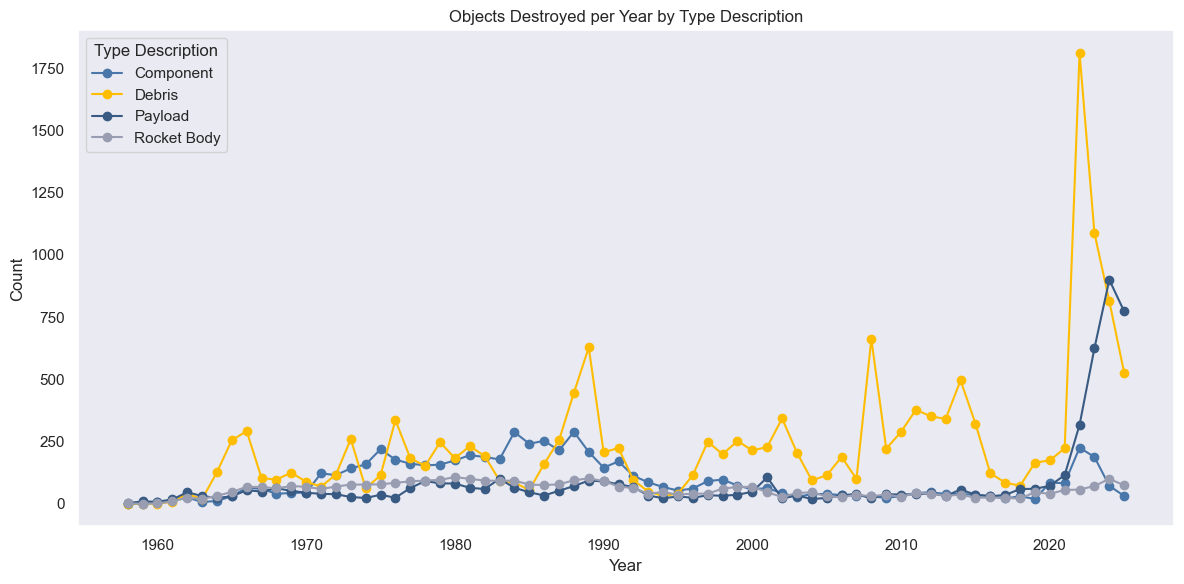

In [ ]:
grouped = sdf.groupby(['DYear', 'TypeDesc']).size().unstack(fill_value=0).sort_index()

grouped.plot(kind='line', marker='o', figsize=(12, 6), color=custom_palette)
plt.title('Objects Destroyed per Year by Type Description')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Type Description')
plt.tight_layout()
plt.show()

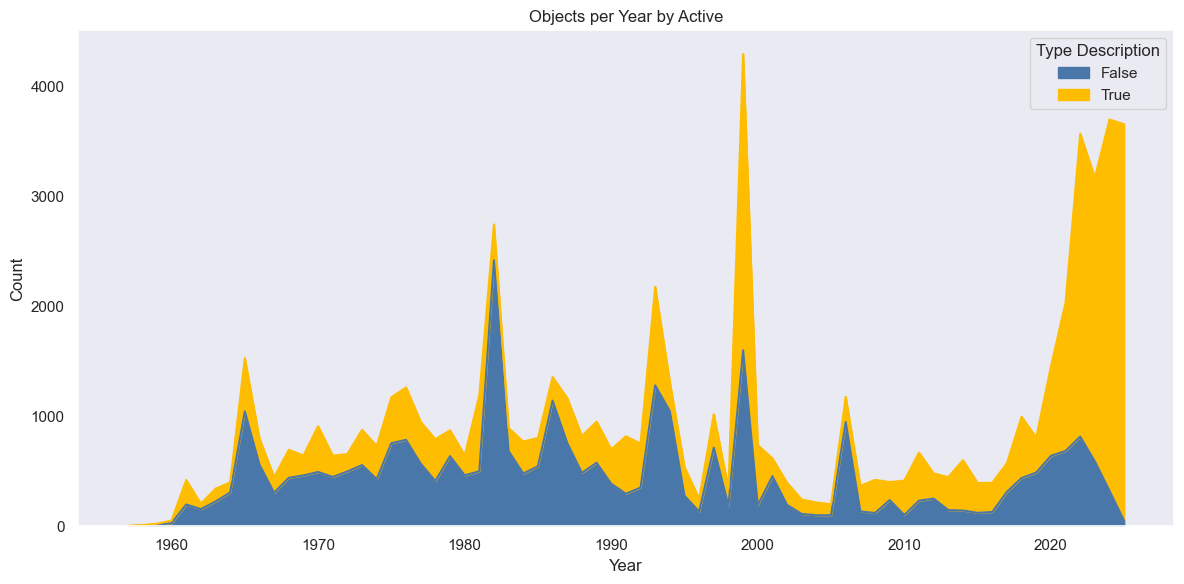

In [ ]:
grouped = sdf.groupby(['LYear', 'Active']).size().unstack(fill_value=0).sort_index()

grouped.plot(kind='area',  figsize=(12, 6),color=custom_palette)
plt.title('Objects per Year by Active')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Type Description')
plt.tight_layout()
plt.show()

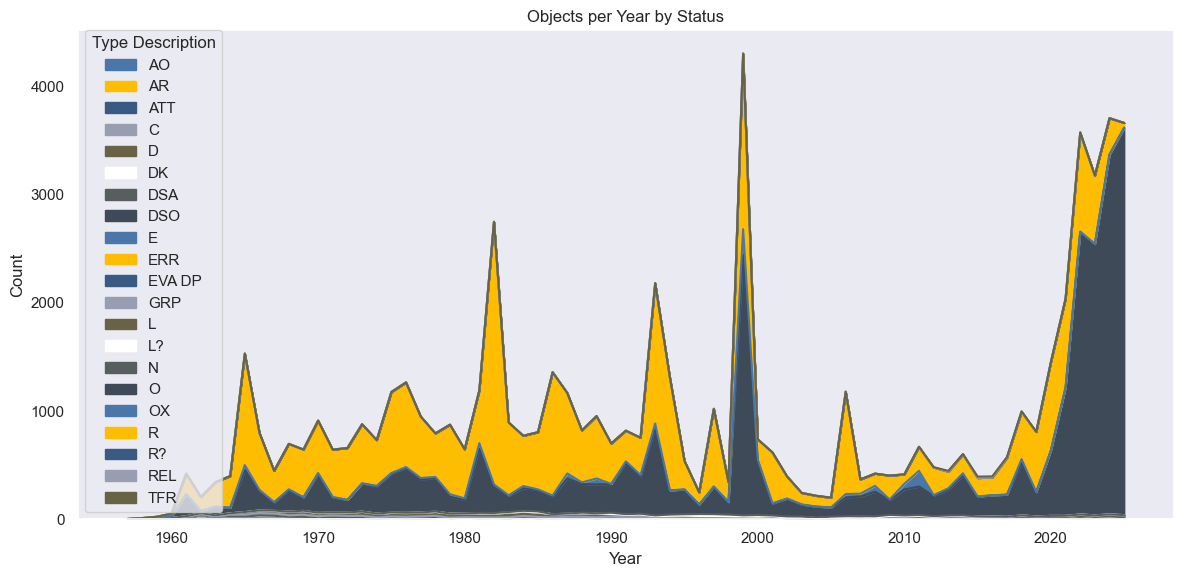

In [ ]:
grouped = sdf.groupby(['LYear', 'Status']).size().unstack(fill_value=0).sort_index()

grouped.plot(kind='area',  figsize=(12, 6),color=custom_palette)
plt.title('Objects per Year by Status')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Type Description')
plt.tight_layout()
plt.show()

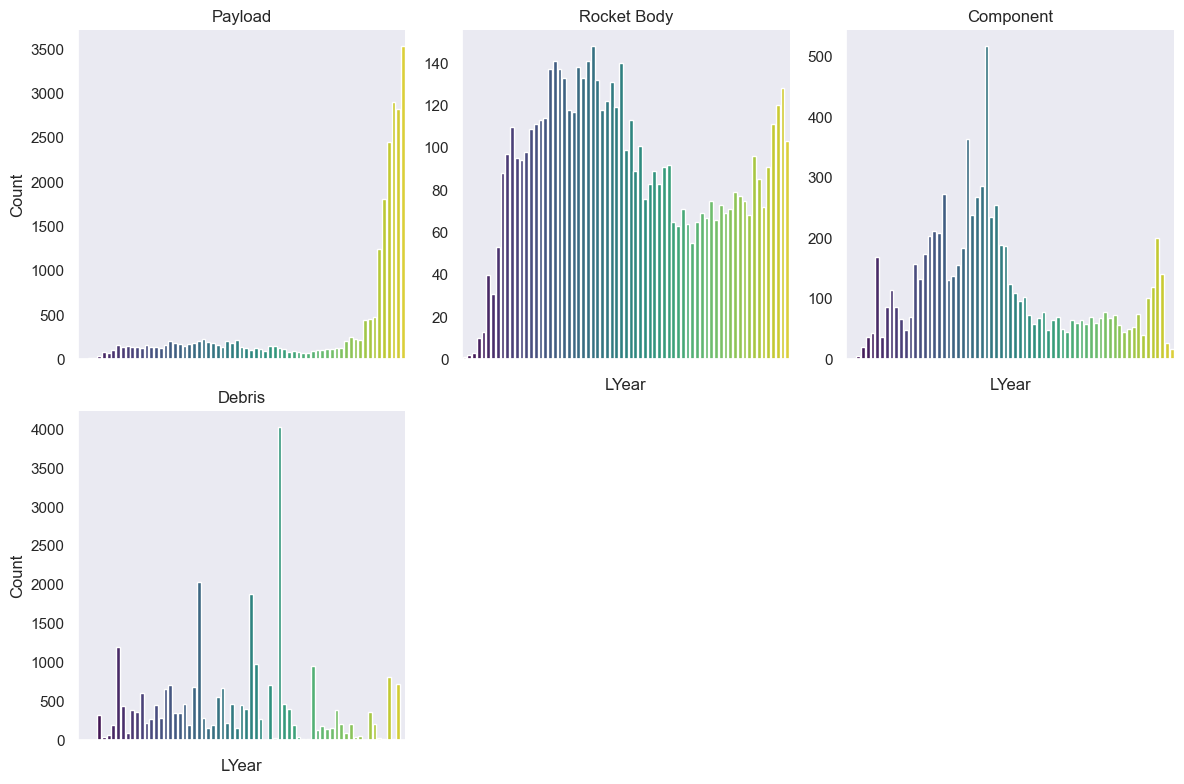

In [ ]:
melted = sdf.groupby(['LYear', 'TypeDesc']).size().reset_index(name='Count')

# Plot
g = sns.FacetGrid(melted, col='TypeDesc', col_wrap=3, height=4, sharey=False)
g.map_dataframe(sns.barplot, x='LYear', y='Count', palette='viridis')
g.set_titles(col_template='{col_name}')
g.set_xticklabels(rotation=45)
plt.tight_layout()
plt.show()

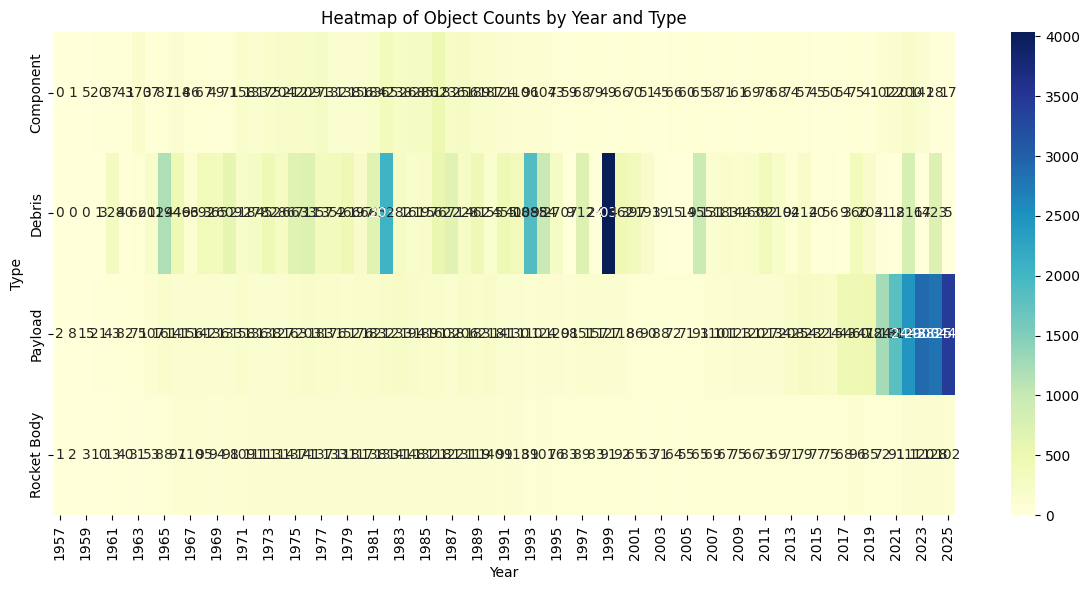

In [ ]:
heatmap_data = sdf.groupby(['LYear', 'TypeDesc']).size().unstack(fill_value=0).sort_index()

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data.T, cmap='YlGnBu', annot=True, fmt='d')
plt.title('Heatmap of Object Counts by Year and Type')
plt.xlabel('Year')
plt.ylabel('Type')
plt.tight_layout()
plt.show()

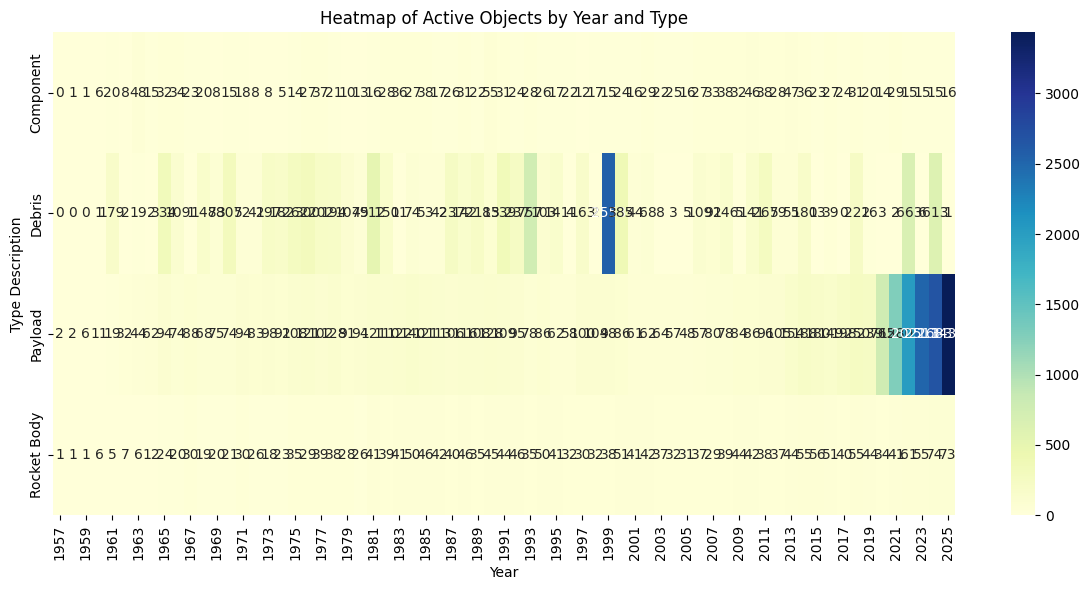

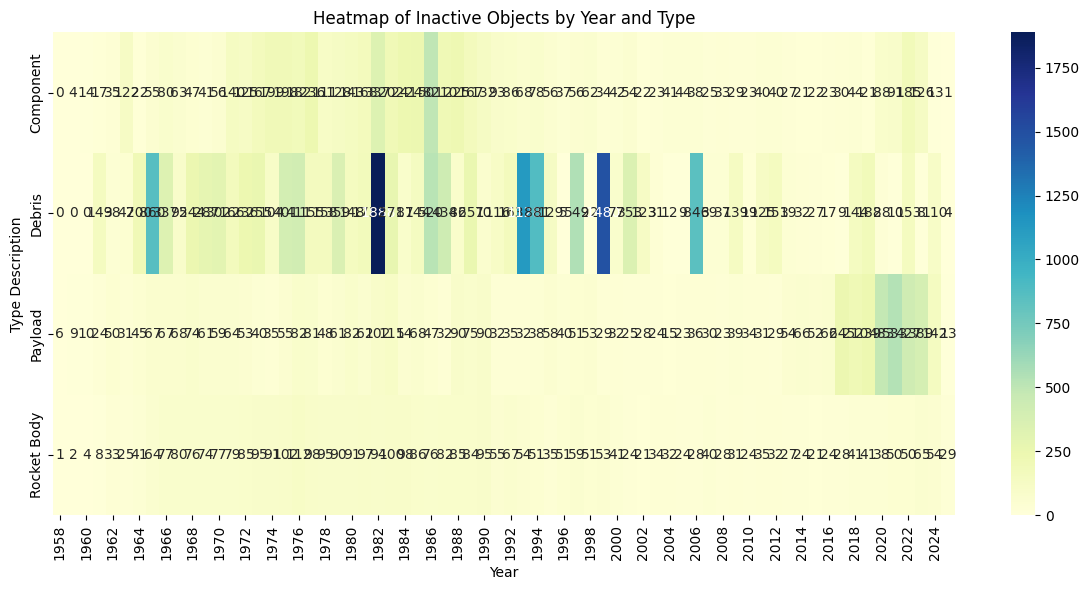

In [ ]:
for status in [True, False]:
    subset = sdf[sdf['Active'] == status]
    heatmap_data = subset.groupby(['LYear', 'TypeDesc']).size().unstack(fill_value=0)

    plt.figure(figsize=(12, 6))
    sns.heatmap(heatmap_data.T, cmap='YlGnBu', annot=True, fmt='d')
    plt.title(f"Heatmap of {'Active' if status else 'Inactive'} Objects by Year and Type")
    plt.xlabel('Year')
    plt.ylabel('Type Description')
    plt.tight_layout()
    plt.show()

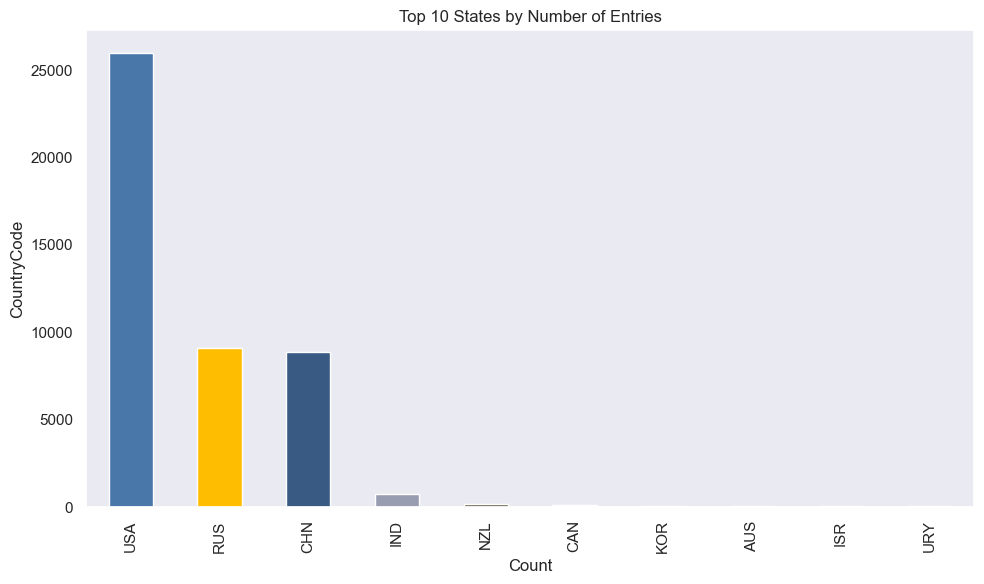

In [ ]:
state_counts = sdf['CountryCode'].value_counts().head(10)

# Plotting a horizontal bar chart
plt.figure(figsize=(10, 6))
state_counts.plot(kind='bar', color=custom_palette)
plt.title('Top 10 States by Number of Entries')
plt.xlabel('Count')
plt.ylabel('CountryCode')
plt.tight_layout()
plt.show()

In [ ]:
owner_counts = sdf['Owner'].value_counts().reset_index()
owner_counts.columns = ['Owner', 'Count']
display(owner_counts)

,Owner,Count
0,SPXS,10482
1,CASC,4353
2,RVSN,4063
3,KVR,3116
4,GSFC,3107
...,...,...
1863,HYDRA/ICH,1
1864,HYDRA,1
1865,ARC/WI,1
1866,IMBP/GUKOSR,1


In [ ]:
orgs_df.columns

Index(['#Code', 'UCode', 'StateCode', 'Type', 'Class', 'TStart', 'TStop',
       'ShortName', 'Name', 'Location', 'Longitude', 'Latitude', 'Error',
       'Parent', 'ShortEName', 'EName', 'UName'],
      dtype='object')

In [ ]:
orgs_df.sample(n=20)

,#Code,UCode,StateCode,Type,Class,TStart,TStop,ShortName,Name,Location,Longitude,Latitude,Error,Parent,ShortEName,EName,UName
2794,PWRD,RDYNE,US,PL/E,B,2005 Aug,2013 Jun,PW/Rocketdyne,Pratt & Whitney Rocketdyne Inc,"Canoga Park, California",-118.6000,34.2000,0.02,UTC2,-,-,Pratt & Whitney Rocketdyne Inc
2353,NAST,NAST,NP,O,C,1982,-,NAST,Nepal Academy of Science and Technology,Kathmandu:Lalitpur,85.3200,27.6500,0.02,-,-,-,Nepal Academy of Science and Technology
3671,USNVA,USNVA,US,O,D,1915,-,USN Norfolk,Naval Station Norfolk,"Norfolk, Virginia",-76.3100,36.9500,0.02,USN,US Navy,-,Naval Station Norfolk
2378,NDRE,NDRE,N,O/LA/PL/S,D,1946,-,NDRE,Forsvarets forskningsinstitutt (FFI),Oslo:Kjeller,11.0300,59.9800,0.02,-,-,Norwegian Defense Research Establishment,Forsvarets forskningsinstitutt (FFI)
3168,SNVL,SNVL,US,PL,B,2009,-,SNC Louisville,Sierra Nevada Corp. Space Systems (Louisville),"Boulder:Louisville, Colorado",-105.1400,39.9800,0.02,-,-,-,Sierra Nevada Corp. Space Systems (Louisville)
3567,UKWO,UKWO,UK,LA,D,1684,1964,UK WO,UK War Office,London:Whitehall,-0.1300,51.5000,0.02,-,-,-,UK War Office
1566,HEX20,HEX20,IN,O,B,2018,-,Hex20Labs,Hex20Labs India Pvt Ltd.,"Thiruvananthapuram, Kerala",76.9400,8.5200,0.02,-,-,-,Hex20Labs India Pvt Ltd.
2064,LRS,LRS,LB,LA/LV/E/LS/S,C,1960,1966,LRS,L'Association Libanaise pour Etudes des Engins...,Beirut:Dbayeh,35.5800,33.9000,0.02,-,LRS,Lebanon Rocket Society,L'Association Libanaise pour l'Étude des Engin...
845,CALP,CALP,US,O/PL/S,A,1901,-,Cal Poly,California Polytechnic State University,"San Luis Obispo, California",-120.6600,35.3000,0.02,-,-,-,California Polytechnic State University
1070,DASAUK,DASAUK,UK,O,D,2015,-,DASA UK,"Defense and Security Accelerator, MoD","Salisbury, Wiltshire",-1.7900,51.0700,0.02,MOD,-,-,"Defense and Security Accelerator, MoD"


In [ ]:
orgs_columns_to_keep = ['#Code', 'UCode', 'ShortName', 'Name', 'EName', 'Longitude', 'Latitude', 'Parent']
odf = orgs_df[orgs_columns_to_keep]
odf.columns

Index(['#Code', 'UCode', 'ShortName', 'Name', 'EName', 'Longitude', 'Latitude',
       'Parent'],
      dtype='object')

In [ ]:
# First, rename odf columns for owner merge
owner_odf = odf.rename(columns=lambda x: f'owner_{x}' if x != '#Code' else 'Owner')

# Merge owner info
sdf = sdf.merge(owner_odf, on='Owner', how='left')

# Optional: repeat for manufacturer with a different prefix
manufacturer_odf = odf.rename(columns=lambda x: f'manu_{x}' if x != '#Code' else 'Manufacturer')
sdf = sdf.merge(manufacturer_odf, on='Manufacturer', how='left')


In [ ]:
sdf.columns

Index(['Piece', 'Type', 'Name', 'LDate', 'DDate', 'Status', 'Owner', 'State',
       'Manufacturer', 'Mass', 'Length', 'Diameter', 'Span', 'Shape',
       'Perigee', 'Apogee', 'Inc', 'LYear', 'DYear', 'LMonth', 'DMonth',
       'EffectiveDDate', 'ActiveDays', 'ActiveMonths', 'ActiveYears',
       'CountryCode', 'TypeDesc', 'Active', 'owner_UCode', 'owner_ShortName',
       'owner_Name', 'owner_EName', 'owner_Longitude', 'owner_Latitude',
       'owner_Parent', 'manu_UCode', 'manu_ShortName', 'manu_Name',
       'manu_EName', 'manu_Longitude', 'manu_Latitude', 'manu_Parent'],
      dtype='object')

In [ ]:
sdf.sample(10)

,Piece,Type,Name,LDate,DDate,Status,Owner,State,Manufacturer,Mass,...,owner_Longitude,owner_Latitude,owner_Parent,manu_UCode,manu_ShortName,manu_Name,manu_EName,manu_Longitude,manu_Latitude,manu_Parent
13009,1981-053EV,D,deb Kosmos-1275,04/06/1981,09/01/2002,R,VMF,SU,-,0.0,...,37.6200,55.7500,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47339,2021-005R,P,Starlink 2079,20/01/2021,NaN,R,SPXS,US,SPXS,260,...,-122.1200,47.6700,-,SPXS,SpaceX/Seattle,SpaceX (Seattle),-,-122.1200,47.6700,-
18566,1987-097A,P,DSP F13,29/11/1987,NaN,O,AFSD,US,TRW,1680.0,...,-118.4100,33.9200,USAF,STL,TRW,TRW Inc.,-,-118.3800,33.8600,-
24497,1994-029VS,D,deb HAPS,19/05/1994,14/01/1998,R,OSCC,US,-,0.0,...,-111.8300,33.3000,OSC,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22379,1992-093CR,D,deb 11S772,25/12/1992,NaN,O,RVSNR,RU,-,0.0,...,37.6200,55.7500,MORF,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34919,2009-027C,C,Briz-M DTB,16/05/2009,NaN,R,KHRR,RU,KHRR,11900,...,37.5000,55.7500,-,KHRU,Khrunichev,"GKNPTs im. M.V. Khrunichev, Roskosmos",Khrunichev State Research and Production Center,37.5000,55.7500,-
53228,2022-086AY,P,Starlink 4162,24/07/2022,NaN,O,SPXS,US,SPXS,297,...,-122.1200,47.6700,-,SPXS,SpaceX/Seattle,SpaceX (Seattle),-,-122.1200,47.6700,-
47609,2021-012Q,P,Starlink 2010,16/02/2021,15/06/2025,R,SPXS,US,SPXS,260,...,-122.1200,47.6700,-,SPXS,SpaceX/Seattle,SpaceX (Seattle),-,-122.1200,47.6700,-
64716,2025-150L,P,Starlink 34660,16/07/2025,NaN,O,SPXS,US,SPXS,575,...,-122.1200,47.6700,-,SPXS,SpaceX/Seattle,SpaceX (Seattle),-,-122.1200,47.6700,-
48021,2021-025E,P,OneWeb SL0116,25/03/2021,NaN,O,ONEWEBN,UK,ONEWUS,148,...,-0.1300,51.5000,-,ONEWUS,One Web,One Web (Florida),-,-80.6000,28.3900,-


In [ ]:
pay_df.columns

Index(['#JCAT', 'Piece', 'Name', 'LDate', 'TLast', 'TOp', 'TDate', 'TF',
       'Program', 'Plane', 'Att', 'Mvr', 'Class', 'Category', 'Result',
       'Control', 'Discipline', 'UNState', 'UNReg', 'UNPeriod', 'UNPerigee',
       'UNApogee', 'UNInc', 'DispEpoch', 'DispPeri', 'DispApo', 'DispInc',
       'Comment'],
      dtype='object')

In [ ]:
payload_columns_to_keep = ['Piece', 'Program', 'Class', 'Category']
pdf = pay_df[payload_columns_to_keep]
pdf.columns

Index(['Piece', 'Program', 'Class', 'Category'], dtype='object')

In [ ]:
sdf = sdf.merge(pdf, on='Piece', how='left')

In [ ]:
sdf.columns

Index(['Piece', 'Type', 'Name', 'LDate', 'DDate', 'Status', 'Owner', 'State',
       'Manufacturer', 'Mass', 'Length', 'Diameter', 'Span', 'Shape',
       'Perigee', 'Apogee', 'Inc', 'LYear', 'DYear', 'LMonth', 'DMonth',
       'EffectiveDDate', 'ActiveDays', 'ActiveMonths', 'ActiveYears',
       'CountryCode', 'TypeDesc', 'Active', 'owner_UCode', 'owner_ShortName',
       'owner_Name', 'owner_EName', 'owner_Longitude', 'owner_Latitude',
       'owner_Parent', 'manu_UCode', 'manu_ShortName', 'manu_Name',
       'manu_EName', 'manu_Longitude', 'manu_Latitude', 'manu_Parent',
       'Program', 'Class', 'Category'],
      dtype='object')

In [ ]:
sdf.sample(10)

,Piece,Type,Name,LDate,DDate,Status,Owner,State,Manufacturer,Mass,...,manu_UCode,manu_ShortName,manu_Name,manu_EName,manu_Longitude,manu_Latitude,manu_Parent,Program,Class,Category
40146,2010-057Y,D,deb CZ-3C Y5,31/10/2010,NaN,O,CASC,CN,CALT,0,...,CALT,CALT,Zhongguo yunzaihuojian jishu yanjiu yuan,Chinese Academy of Launch Vehicle Technology (...,116.3900,39.7800,CASC,NaN,NaN,NaN
47531,2021-009J,P,Starlink 1955,04/02/2021,NaN,O,SPXS,US,SPXS,260,...,SPXS,SpaceX/Seattle,SpaceX (Seattle),-,-122.1200,47.6700,-,Starlink 1.0V2,B,COM
54386,2022-151FX,D,deb CZ-6A Y2,11/11/2022,NaN,O,CNSA,CN,SAST,0,...,SBA,SAST,Shanghai hangtian jishu yanjiuyuan,Shanghai Academy of Space Technology (CASC 8th...,121.3800,31.1100,CASC,NaN,NaN,NaN
65973,2025-235A,P,Starlink 35552,19/10/2025,NaN,O,SPXS,US,SPXS,575.0,...,SPXS,SpaceX/Seattle,SpaceX (Seattle),-,-122.1200,47.6700,-,Starlink 2MO S1,B,COM
4317,1969-082DU,D,deb Agena D,30/09/1969,01/12/2012,R,SAMSO,US,-,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
561,1963-007A,P,OPS 0720,01/04/1963,26/04/1963,AR,NRO/CIA,US,LMSC,215.0,...,LMSC,LMSC,Lockheed Missiles and Space Co.,-,-122.0400,37.3700,LAC,CORONA M,D,IMG
54389,2022-151GA,D,deb CZ-6A Y2,11/11/2022,NaN,O,CNSA,CN,SAST,0,...,SBA,SAST,Shanghai hangtian jishu yanjiuyuan,Shanghai Academy of Space Technology (CASC 8th...,121.3800,31.1100,CASC,NaN,NaN,NaN
25475,1985-056G,D,deb Ariane V14,02/07/1985,11/03/2002,R,AE,F,-,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49151,2021-082BD,P,Starlink 3059,14/09/2021,NaN,O,SPXS,US,SPXS,297,...,SPXS,SpaceX/Seattle,SpaceX (Seattle),-,-122.1200,47.6700,-,Starlink 1.5 G2,B,COM
54186,2022-111AS,C,BW3 LVA,11/09/2022,09/03/2025,R,ASTS,US,ASTS,150,...,ASTS,AST & Science,Avellan Space Technology and Science,-,-102.2100,31.9400,-,NaN,NaN,NaN


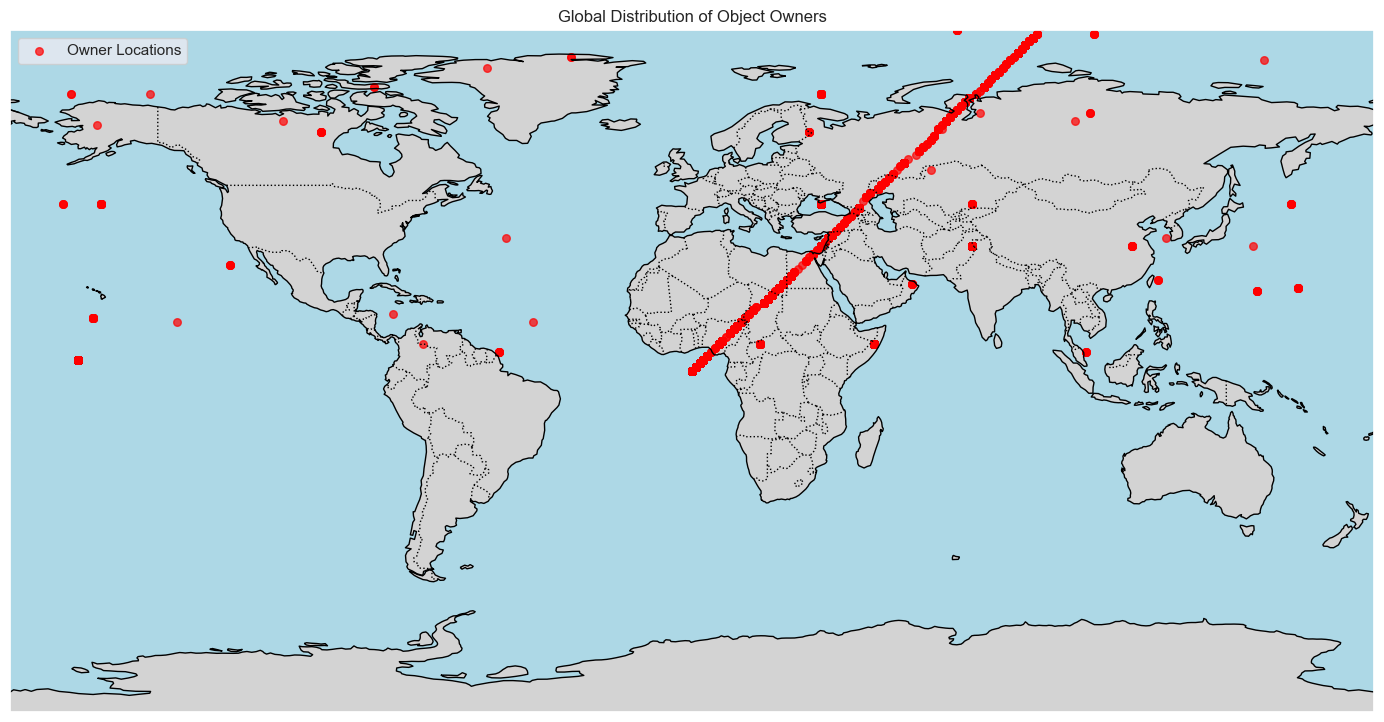

In [ ]:
# Drop rows with missing coordinates
sdf_clean = sdf.dropna(subset=['owner_Latitude', 'owner_Longitude'])

# Create the map
plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

# Plot points
ax.scatter(
    sdf_clean['owner_Longitude'],
    sdf_clean['owner_Latitude'],
    color='red',
    s=30,
    alpha=0.7,
    transform=ccrs.PlateCarree(),
    label='Owner Locations'
)

plt.title('Global Distribution of Object Owners')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
world = gpd.read_file("ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")


In [ ]:
# Count satellites per country
state_counts = sdf['CountryCode'].value_counts().reset_index()

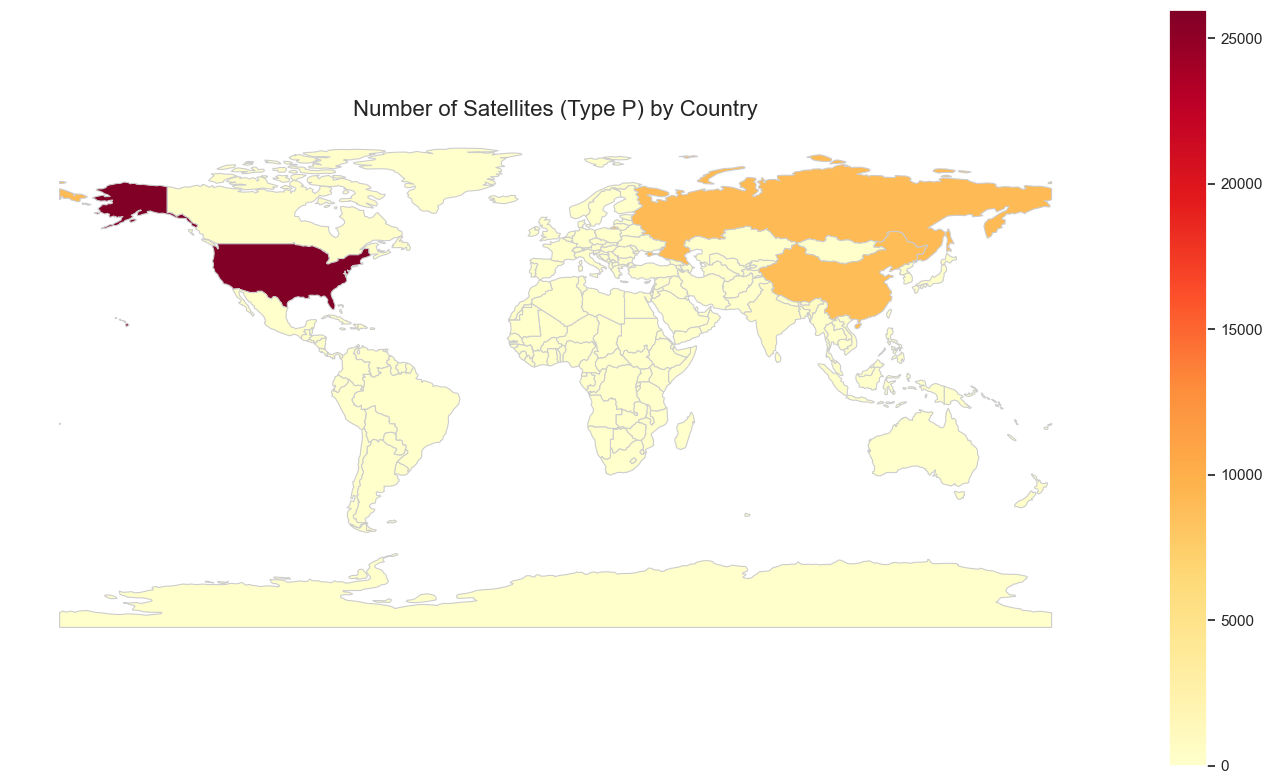

In [ ]:


state_counts.columns = ['ADM0_ISO', 'SatelliteCount']

# Load world map with ISO codes
world = gpd.read_file("ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")
#world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Merge using ISO alpha-3 codes
merged = world.merge(state_counts, on='ADM0_ISO', how='left')

# Fill missing counts with 0
merged['SatelliteCount'] = merged['SatelliteCount'].fillna(0)

# Plotting
fig, ax = plt.subplots(figsize=(14, 8))
merged.plot(column='SatelliteCount', cmap='YlOrRd', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
ax.set_title('Number of Satellites (Type P) by Country', fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()

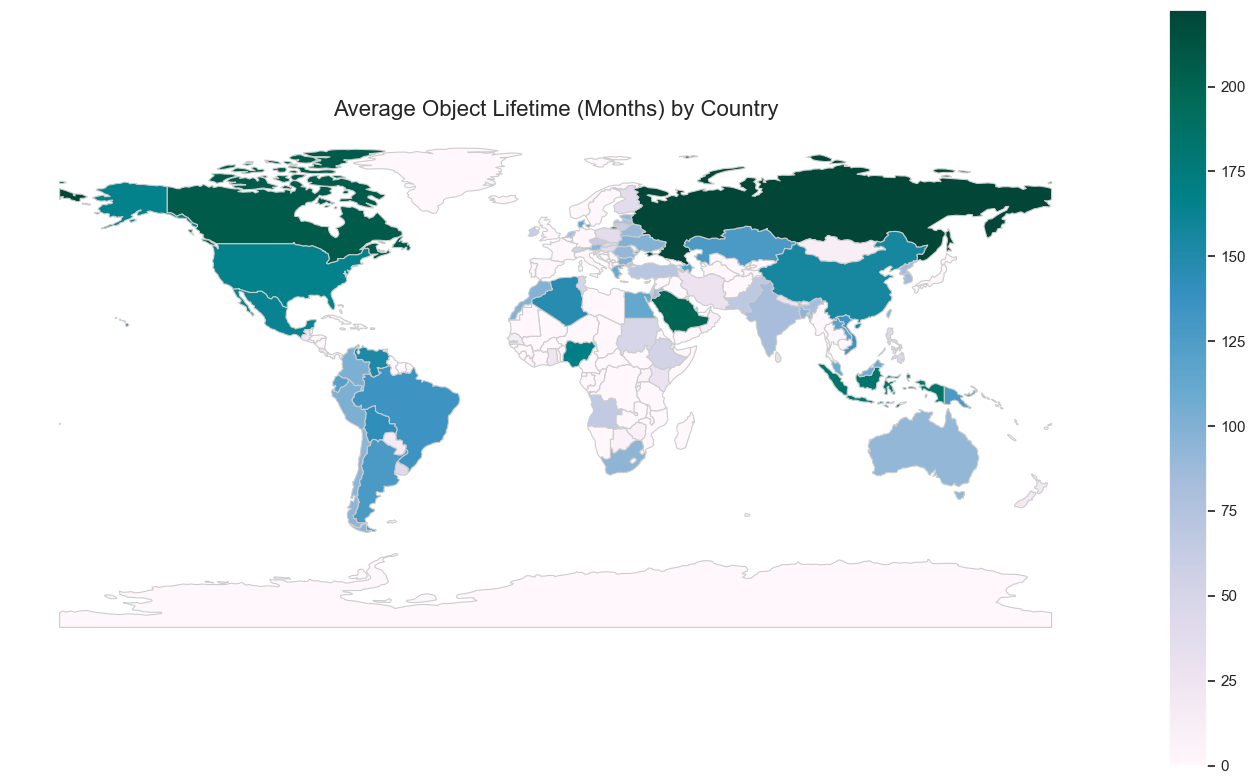

In [ ]:
avg_months = sdf.groupby('CountryCode')['ActiveMonths'].mean().reset_index()
avg_months.columns = ['ADM0_A3', 'AvgMonths']
merged = world.merge(avg_months, on='ADM0_A3', how='left')
merged['AvgMonths'] = merged['AvgMonths'].fillna(0)
fig, ax = plt.subplots(figsize=(14, 8))
merged.plot(column='AvgMonths', cmap='PuBuGn', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
ax.set_title('Average Object Lifetime (Months) by Country', fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()

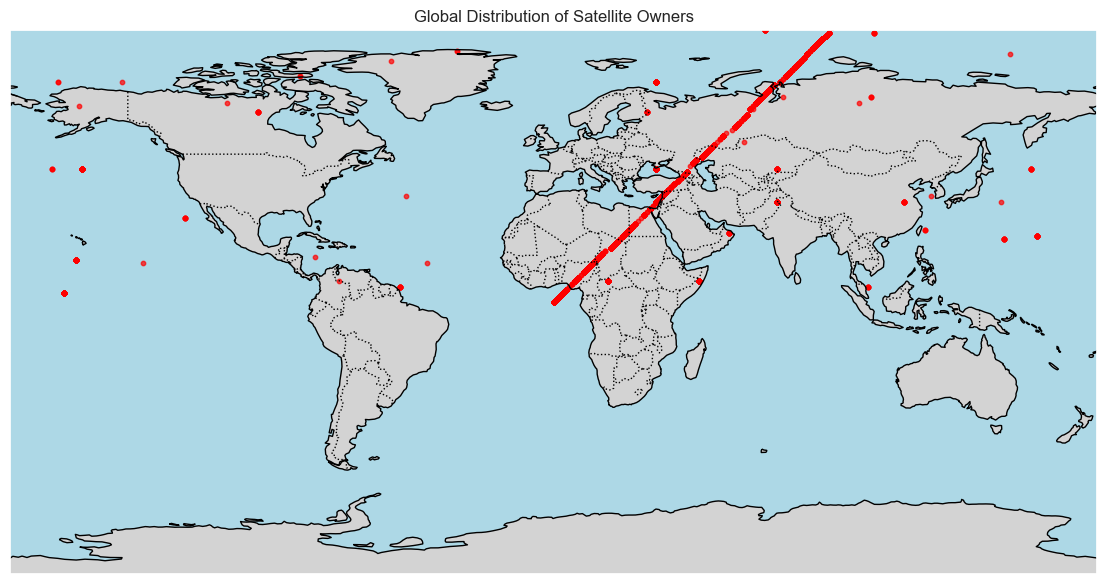

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Filter valid coordinates
location_df = sdf[['owner_Name', 'owner_Longitude', 'owner_Latitude']].dropna()

# Create the map
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

# Plot satellite owner locations
ax.scatter(
    location_df['owner_Longitude'],
    location_df['owner_Latitude'],
    color='red',
    s=10,
    alpha=0.7,
    transform=ccrs.PlateCarree()
)

plt.title('Global Distribution of Satellite Owners')
plt.tight_layout()
plt.show()


In [ ]:
sdf.columns

Index(['Piece', 'Type', 'Name', 'LDate', 'DDate', 'Status', 'Owner', 'State',
       'Manufacturer', 'Mass', 'Length', 'Diameter', 'Span', 'Shape',
       'Perigee', 'Apogee', 'Inc', 'LYear', 'DYear', 'LMonth', 'DMonth',
       'EffectiveDDate', 'ActiveDays', 'ActiveMonths', 'ActiveYears',
       'CountryCode', 'TypeDesc', 'Active', 'owner_UCode', 'owner_ShortName',
       'owner_Name', 'owner_EName', 'owner_Longitude', 'owner_Latitude',
       'owner_Parent', 'manu_UCode', 'manu_ShortName', 'manu_Name',
       'manu_EName', 'manu_Longitude', 'manu_Latitude', 'manu_Parent',
       'Program', 'Class', 'Category'],
      dtype='object')

In [ ]:
# Split the Category column at the first '/'
split_cols = sdf['Category'].str.split('/', n=1, expand=True)

# Remove trailing spurious characters from each part
sdf['PriCategory'] = split_cols[0].str.strip().str.replace(r'[*?]+$', '', regex=True)
sdf['SecCategory'] = split_cols[1].str.strip().str.replace(r'[*?]+$', '', regex=True) if split_cols.shape[1] > 1 else None

In [ ]:
sdf.to_csv('../../datasets/sdf.csv')

# NEED TO FINISH THIS SECTION

Idea notes:

Graphs to Draw

Disteibution curves

Life time of object in years vs type


—. Box plot 
ployly interactive box plot

Bar charts

X = top 10 countries for satellites
Y = Counts of 


Per top ten countries (and second chart for owner), by year, violin plot for active or not?

Objects which appear and disappear in the same year. (< 12 months)

How much debris is still in orbit? 
Percentage of the debris that belongs to a given country / owner.

Parent… if there is no parent, copy owner?

Class and Categories



Presentation

- Discuss the Issue
- Discuss the types of satellite out there - class and category

Life span… 
By company — 
By type and class


Sunburst. — country… then class/.

- 


In [70]:
class_json = {
  "A": "Academic / Amateur / Non-Profit",
  "B": "Commercial",
  "C": "Government (Civil)",
  "D": "Government (Defence / Military / Intelligence)",
}

category_json = {
  
  
  
}


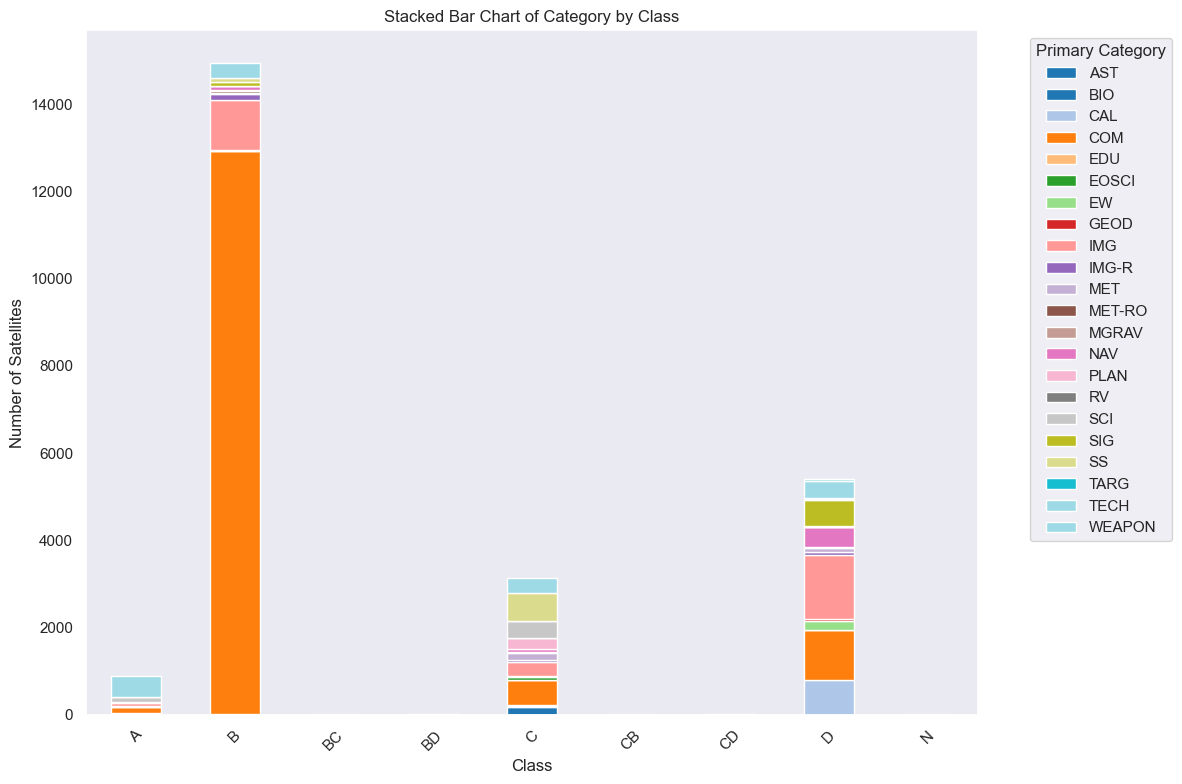

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

# Group and count the data
grouped = sdf.groupby(['Class', 'PriCategory']).size().unstack(fill_value=0)

# Create the stacked bar chart
grouped.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 8),
    colormap='tab20'
)

# Customize the plot
plt.title('Stacked Bar Chart of Category by Class')
plt.xlabel('Class')
plt.ylabel('Number of Satellites')
plt.xticks(rotation=45)
plt.legend(title='Primary Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


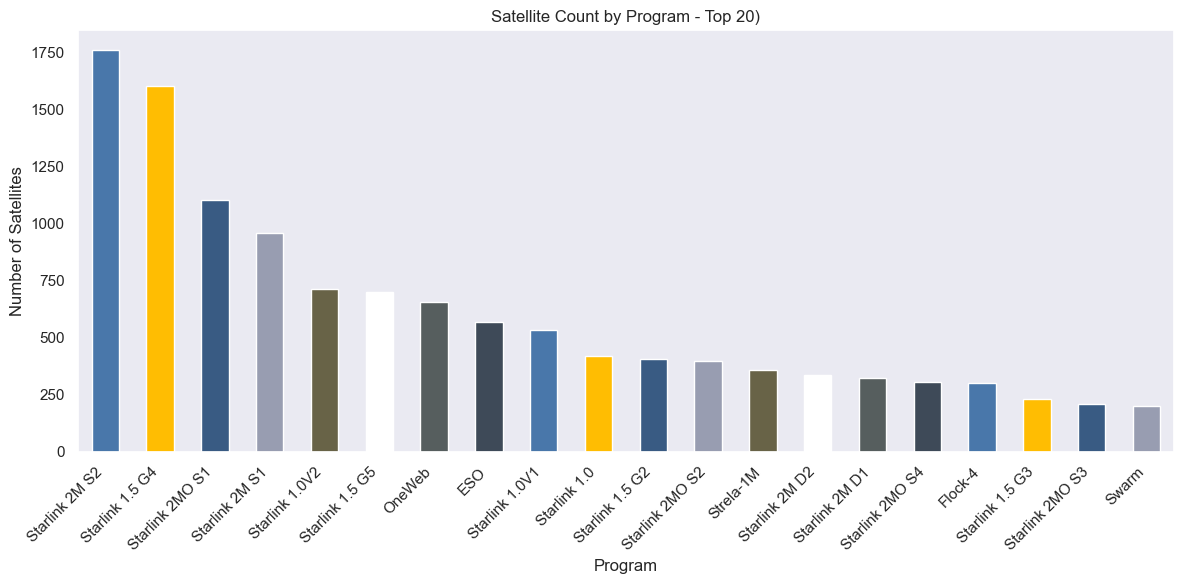

In [72]:
# Filter out empty or null Program entries
filtered_df = sdf[sdf['Program'].notna() & (sdf['Program'].str.strip() != '')]

# Count satellites per Program
program_counts = filtered_df['Program'].value_counts().sort_values(ascending=False).head(20)

# Create the bar chart
plt.figure(figsize=(12, 6))
program_counts.plot(kind='bar', color=custom_palette)

# Customize the plot
plt.title('Satellite Count by Program - Top 20)')
plt.xlabel('Program')
plt.ylabel('Number of Satellites')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

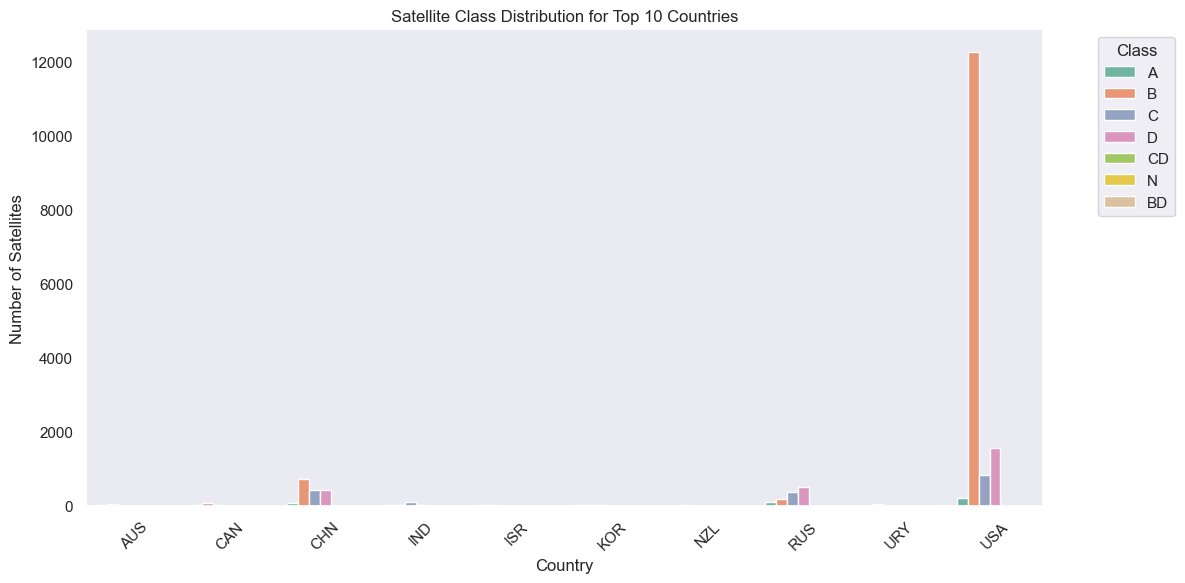

In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get top 10 countries by satellite count
top_countries = sdf['CountryCode'].value_counts().nlargest(10).index

# Filter for top countries
filtered_df = sdf[sdf['CountryCode'].isin(top_countries)]

# Group by CountryCode and Class
grouped = filtered_df.groupby(['CountryCode', 'Class']).size().reset_index(name='Count')

# Create the grouped bar chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=grouped,
    x='CountryCode',
    y='Count',
    hue='Class',
    palette='Set2'
)

# Customize the plot
plt.title('Satellite Class Distribution for Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Number of Satellites')
plt.xticks(rotation=45)
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

